# Mesh damage lab

Tight-loop iteration on `disaster/mesh_damage.py` against **any single asset** —
Nucleus, objaverse, an `airstack://` pack, or a file on disk.

**Kernel: `airstack (3.11)`.** Everything here runs in that one env.

### Why this is trustworthy

Every cell is wrecked by `damage_gallery.build_cell`, which calls
`disaster_stage.apply_to_buildings` -> `scene_generator.apply_placements` ->
`mesh_damage.apply_to_stage` — the same three functions `generate_scene` calls,
in the same order, off a config `compile_disaster.py` compiled. **No damage
logic is reimplemented here.** If a failure field stops
breaking anything, this notebook shows it.

Two deliberate differences from a real `airstack up`, both required to damage
one building instead of a city:

| | in a scene | here |
|---|---|---|
| damage field | varies with position | pinned uniform at **1.0**, so intensity == `severity` |
| fate | rolled per building | forced to `fate=` so the cell is never blank |

Everything downstream — which failure field, where it fails, what comes free,
what thickens, what debris drops — is the generator's own code.

> **Budgets don't bite with one building.** `fracture.max_buildings` and
> `thickness.max_buildings` ration work across a city; here they always include
> it. So `thickened=0` means `solidify` *declined* the mesh (already solid), not
> that it ran out of budget.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath("../tools"))
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import damage_lab as dl

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("damage lab ready —", sys.version.split()[0])

damage lab ready — 3.11.15


## 1. Pick an asset

`resolve()` tells the sources apart by shape and fetches whatever is missing:

| you type | what happens |
|---|---|
| `omniverse://.../Library/Stages/<pack>/x.usd` | mirrored via `tools/nucleus.py` into `assets/nucleus/` |
| `objaverse://<uid>` or a bare 32-hex uid | objaverse cache, downloading + converting (bpy, subprocess) if needed |
| `airstack://<path>` | resolved against the repo's own packs |
| `/abs/path.usd`, `relative/path.usdc` | used as-is |

**`scale` and `axis_up` belong to the placement, not the file.** Nucleus/AEC
content is centimetre-authored (`scale=0.01`, the default for that source);
objaverse is already metric (`1.0`). Getting this wrong is what once threw
debris kilometres out of the region, so `resolve()` shows you what it picked.

In [2]:
# --- Nucleus -------------------------------------------------------------
asset = dl.resolve(
    "omniverse://airlab-nucleus.andrew.cmu.edu:443"
    "/Library/Stages/Muyang/DownTown/Assets/BG_Building_B.usd",
    quiet=False)

# --- or a local / objaverse asset ----------------------------------------
# asset = dl.resolve("objaverse://6644de89c2f0449db3de934744162b63")
# asset = dl.from_asset_set("suburban")[0]

print(f"{asset['source']:10s} scale={asset['scale']}  axis_up={asset['axis_up']}")
print(asset["usd"])

nucleus    scale=0.01  axis_up=Z
/home/myan2/coasei/AirStack/scene_gen/assets/nucleus/Muyang/DownTown/Assets/BG_Building_B.usd


### What else is available

`from_asset_set(name)` lists the buildings of a real asset set that are on
disk — damage the same library a scene would.

In [3]:
for s in ("suburban", "urban_intact_local"):
    try:
        b = dl.from_asset_set(s)
        print(f"{s:22s} {len(b):3d} on disk   e.g. {b[0]['label'] if b else '-'}")
    except Exception as e:
        print(f"{s:22s} {type(e).__name__}: {e}")

# Browse Nucleus without leaving the notebook:
# import nucleus
# for n, size, is_dir in nucleus.ls("omniverse://.../Assets/")[:20]:
#     print(("d" if is_dir else "-"), f"{size:>10,}", n)

suburban                15 on disk   e.g. 6644de89c2f0449db3de934744162b63.usdc
urban_intact_local       9 on disk   e.g. SM_MERGED_BP_MBuilding01.usd


## 2. One shot

`damage()` returns the cell report *and* writes the USD to `scene_gen/_damage_lab/`.
The caption is ground truth about what ran:

- `field` — which of `earthquake` / `explosion` / `tornado` / `hurricane` / `fire` / `flood`
- `fragments` / `loose` — Voronoi cells cut, and how many came free of the structure
- `thickened` — meshes `solidify` actually extruded (0 = declined, or the
  building was dismissed before stage one because nothing would ever release)
- `debris` / `debris_pile` — what the disaster stage scattered
- `soot` — materials `scorch` recoloured

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
BG_Building_B_earthquake_s1.0: field=earthquake  fragments=31 (loose 31)  thickened=1  debris=8/3  soot=0


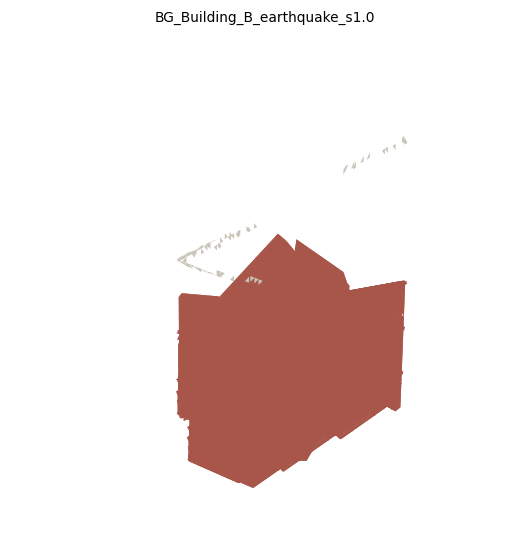

In [4]:
r = dl.damage(asset, "earthquake", severity=1.0, seed=7, fate="damaged")
print(dl.summarize(r))
dl.preview(r, show_debris=False);

## 3. Turn the knobs

`overrides` is deep-merged into the compiled `disaster:` block **after**
`compile_disaster` produces it — exactly where a preset's own overrides land.
So anything a preset can say, you can say here.

```python
overrides={
  "mesh_damage": {
    "fracture": {"enabled": True,
                 "fragment_m": 1.5,    # world size of a chunk of rubble
                 "min_cells": 6, "max_cells": 120,
                 "support": 0.12,      # damage at which material is cut at all
                 "release": 0.5,       # …at which a fragment comes free
                 "collapse": 0.8},     # …below it, at which it loses support
    "thickness": {"enabled": True, "wall_m": 0.5,
                  "max_span_frac": 0.35, "max_points": 200000},
  },
  "debris": {"pieces_per_building": [40, 60], "pieces_scatter_m": 9.0},
}
```

The fracture keys that reach the pipeline are `mesh_damage.FRACTURE_KEYS`:
`fragment_m, min_cells, max_cells, support, release, collapse, neighbors,
min_faces, cap`. Everything else about the damage is the **failure field**,
keyed off the disaster type — see `mesh_damage.FAILURE_FIELDS`.

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)


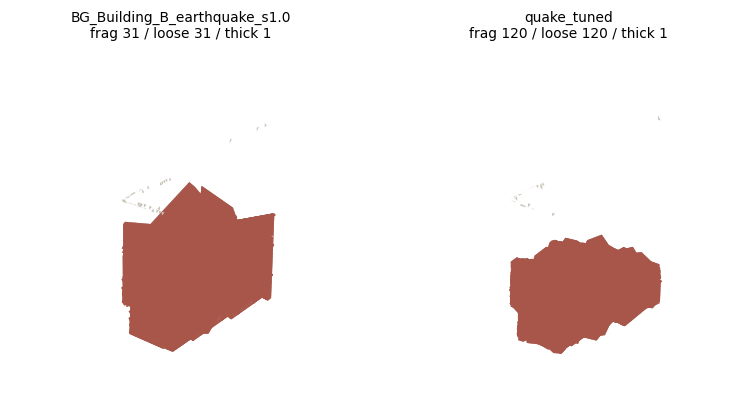

In [5]:
tuned = dl.damage(asset, "earthquake", severity=0.9, seed=7,
                  overrides={"mesh_damage": {
                      "fracture": {"fragment_m": 1.2, "max_cells": 120},
                      "thickness": {"wall_m": 0.4},
                  }},
                  name="quake_tuned")
dl.grid([r, tuned], cols=2, show_debris=False);

## 4. Sweeps

`sweep()` takes either a `damage()` argument (`severity`, `seed`, `disaster`,
`fate`) or a **dotted path into `overrides`**.

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)


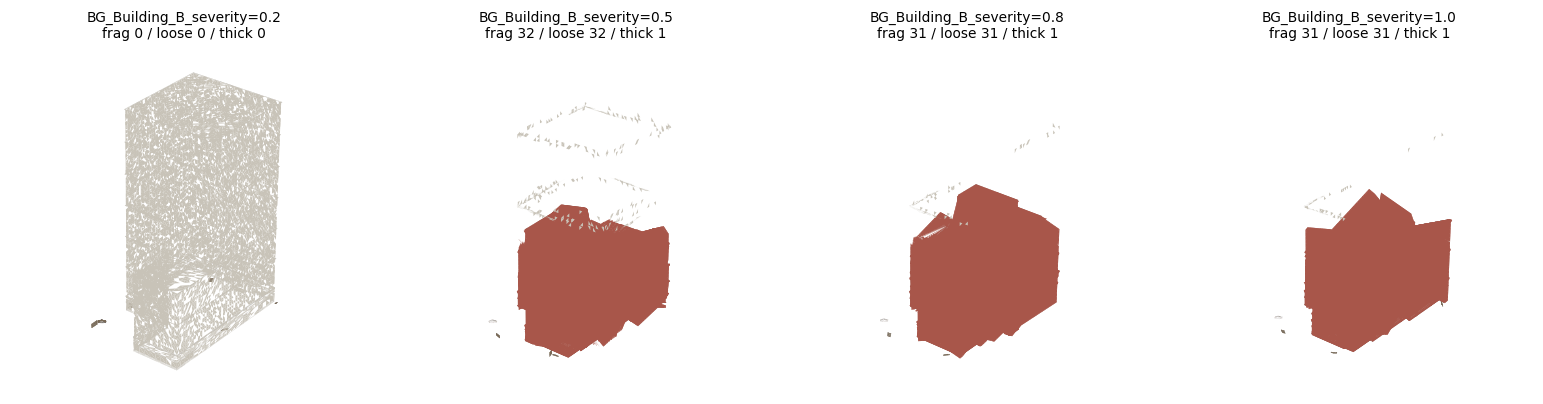

In [6]:
_ = dl.sweep(asset, [0.2, 0.5, 0.8, 1.0], key="severity", seed=7, cols=4)

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)


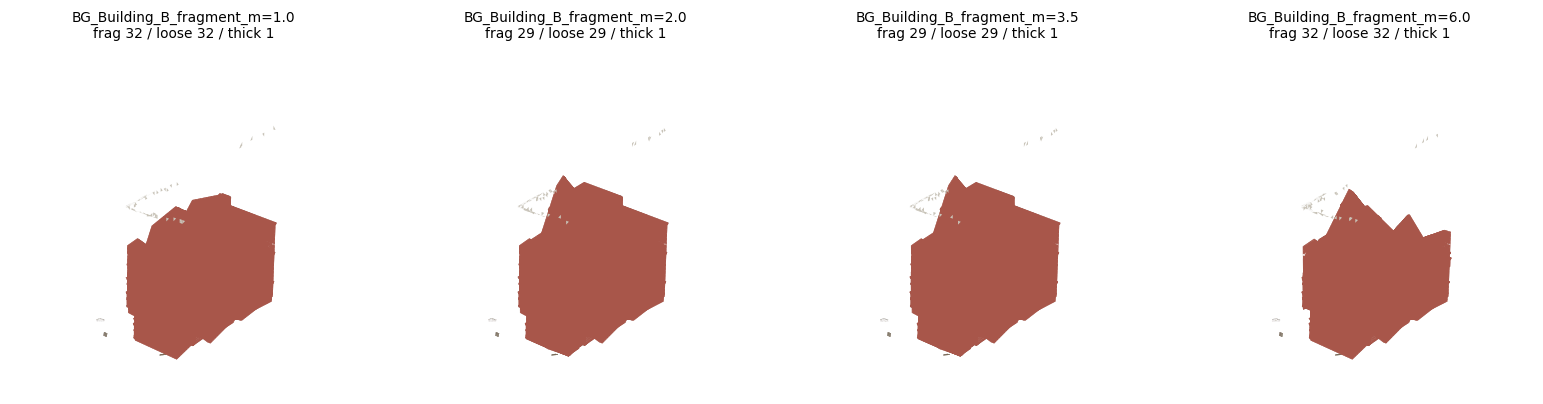

In [7]:
_ = dl.sweep(asset, [1.0, 2.0, 3.5, 6.0],
             key="mesh_damage.fracture.fragment_m",
             severity=0.9, seed=7, cols=4)

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)


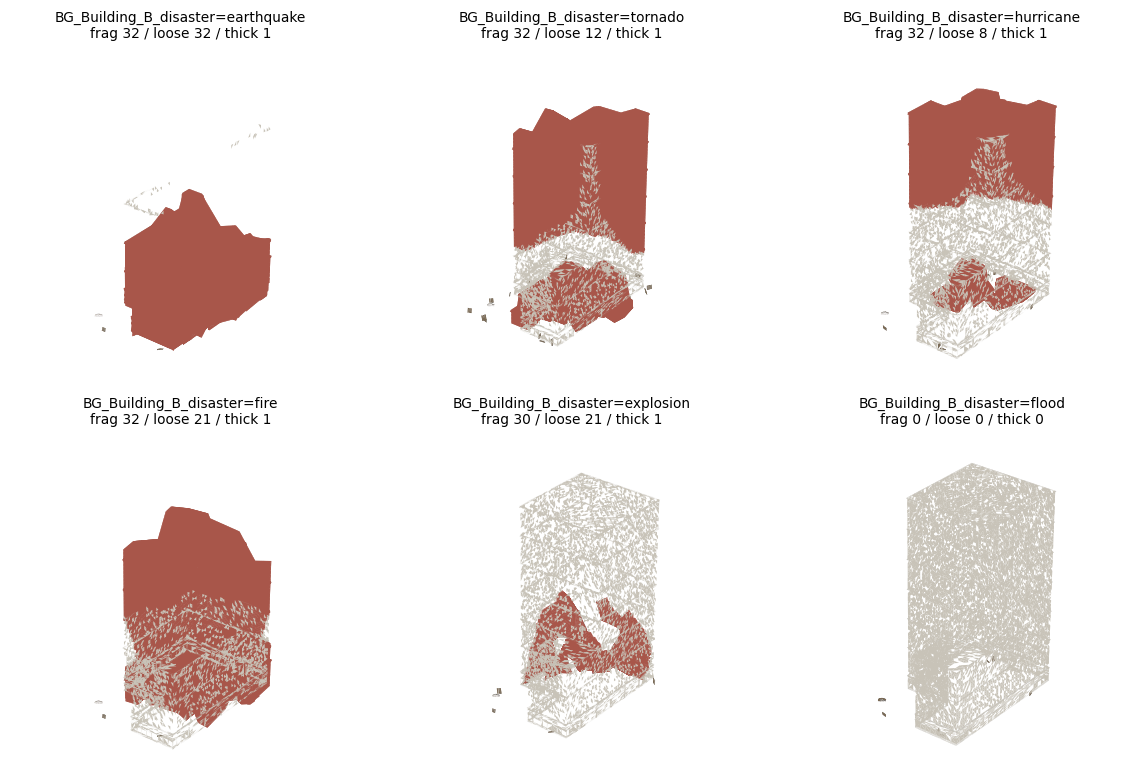

In [8]:
# All six failure fields on the same asset, same seed — the shape comparison.
_ = dl.sweep(asset, ["earthquake", "tornado", "hurricane", "fire",
                     "explosion", "flood"],
             key="disaster", severity=0.85, seed=7, cols=3)

## 6. Debris, and the mesh underneath it

`show_debris=False` hides what the disaster stage scattered so you can see what
the *mesh damage* did. The building is bit-identical either way — `build_cell`
lets the stage run in full and discards the debris afterwards, so the two differ
in exactly one variable rather than in the RNG stream.

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)


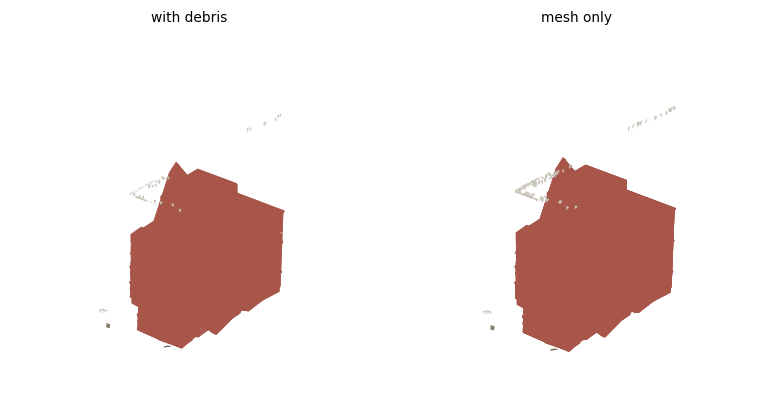

In [9]:
both = dl.damage(asset, "earthquake", severity=0.9, seed=7,
                 debris=True, name="dbg_pair")
fig = dl.grid([both, both], cols=2, show_debris=True, captions=False, size=3.6)
fig.axes[0].set_title("with debris", fontsize=9)
dl.preview(both, ax=fig.axes[1], show_debris=False, title="mesh only");

## 7. Actually render it

Three ways to look at a result, in increasing cost and fidelity:

| | what it is | cost | answers |
|---|---|---|---|
| `preview()` | flat matplotlib triangles | <1 s | did it lean / shear / shatter? |
| `render_gl()` | **lit + shadowed, in this kernel** | ~0.3 s a tile | does the damage read? |
| `render()` | Cycles via Blender | ~1 s a tile | does it look right? |

`render_gl()` uses `pyrender` on EGL — already a dependency of this env, runs on
the GPU headless, no subprocess. Geometry, lighting, shadows and soot are real;
the asset's own **textures and shaders are not read** (surfaces are coloured by
category), because `usd-core` ships no Hydra. When materials matter, use
`render()`.

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)


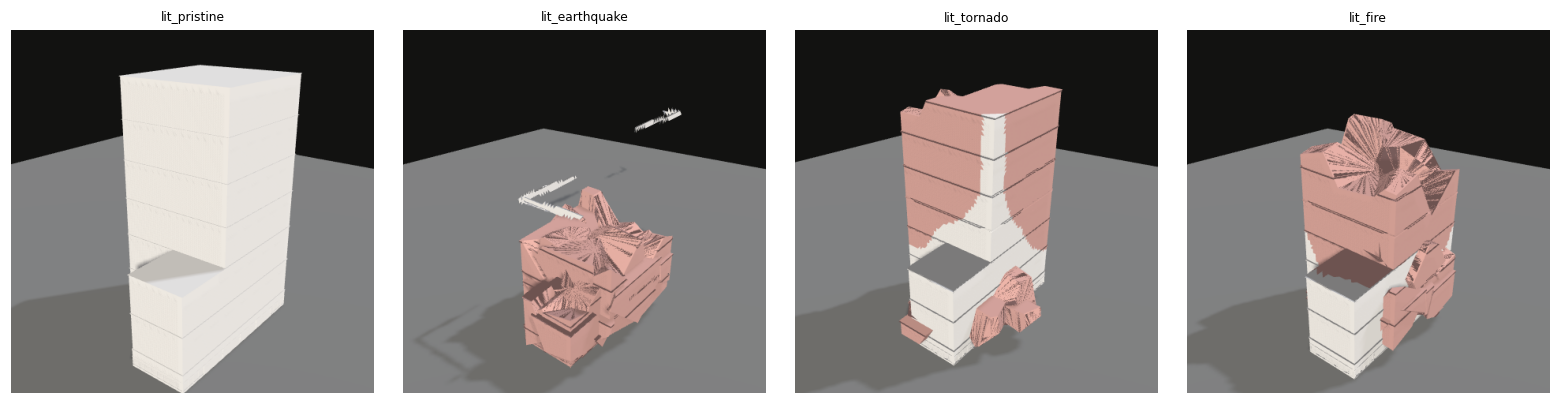

In [10]:
imgs = dl.grid_gl(
    [dl.damage(asset, d, 0.85, seed=7, name=f"lit_{d}")
     for d in ("pristine", "earthquake", "tornado", "fire")],
    cols=4, res=460, show_debris=False)

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)


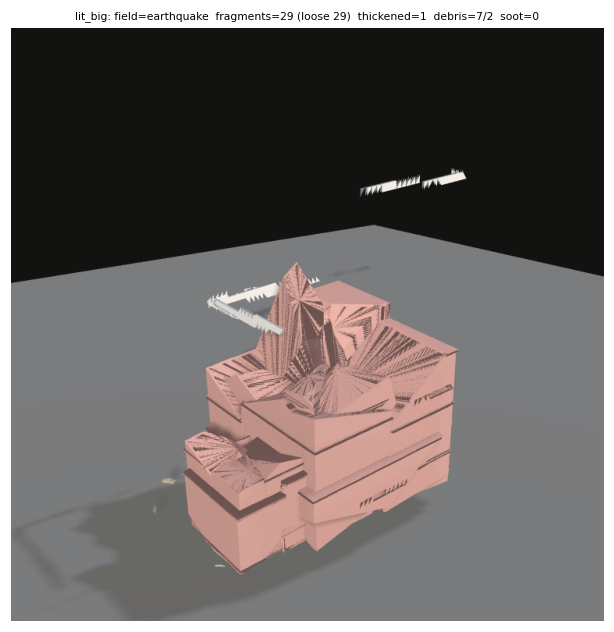

In [11]:
# One big one, with the debris field in place.
dl.render_gl(dl.damage(asset, "earthquake", 0.9, seed=7, name="lit_big"),
             res=760, azim=52, elev=18);

### Cycles, when you want materials

`render()` writes the manifest `render_damage_gallery.py` consumes and runs it
under `uv run --script`, which builds its own Python 3.13 `bpy` environment on
demand — **`bpy` never has to be installed in this kernel**, which is the whole
point of the PEP 723 pattern the repo already uses.

A row is framed on its first cell, so `frame_on_pristine=True` (the default)
prepends an undamaged cell: otherwise the camera pulls back to fit thrown debris
and a *more* damaged cell renders *smaller*, which reads as scale rather than
damage. Soot is carried through the manifest because Blender's USD importer
drops `inputs:scale`, where `scorch` writes charring.

[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[scene_gen] measured house: BG_Building_B.usd -> 6026.84 x 4020.04 m (unit scale, up=Z)
[damage_lab] uv run --script /home/myan2/coasei/AirStack/scene_gen/tools/render_damage_gallery.py /home/myan2/coasei/AirStack/scene_gen/_damage_lab/render/manifest.json --res 420 --samples 24 --az 38.0 --el 20.0
00:00.387  cycles           | WARNING HIPEW initialization failed: Error opening HIP dynamic library
[render] GPU/OPTIX (NVIDIA GeForce RTX 5090)  420px  24 samples
USD import of '/home/myan2/coasei/AirStack/scene_gen/_damage_lab/frame_r0.usd' took 52.71 ms
00:01.156  render           | Saved: '/home/myan2/coasei/AirStack/scene_gen/_damage_lab/render/tiles/00_BG_Building_B/_frame_r0.png'
  [0] BG_Building_B          _frame_r0      0

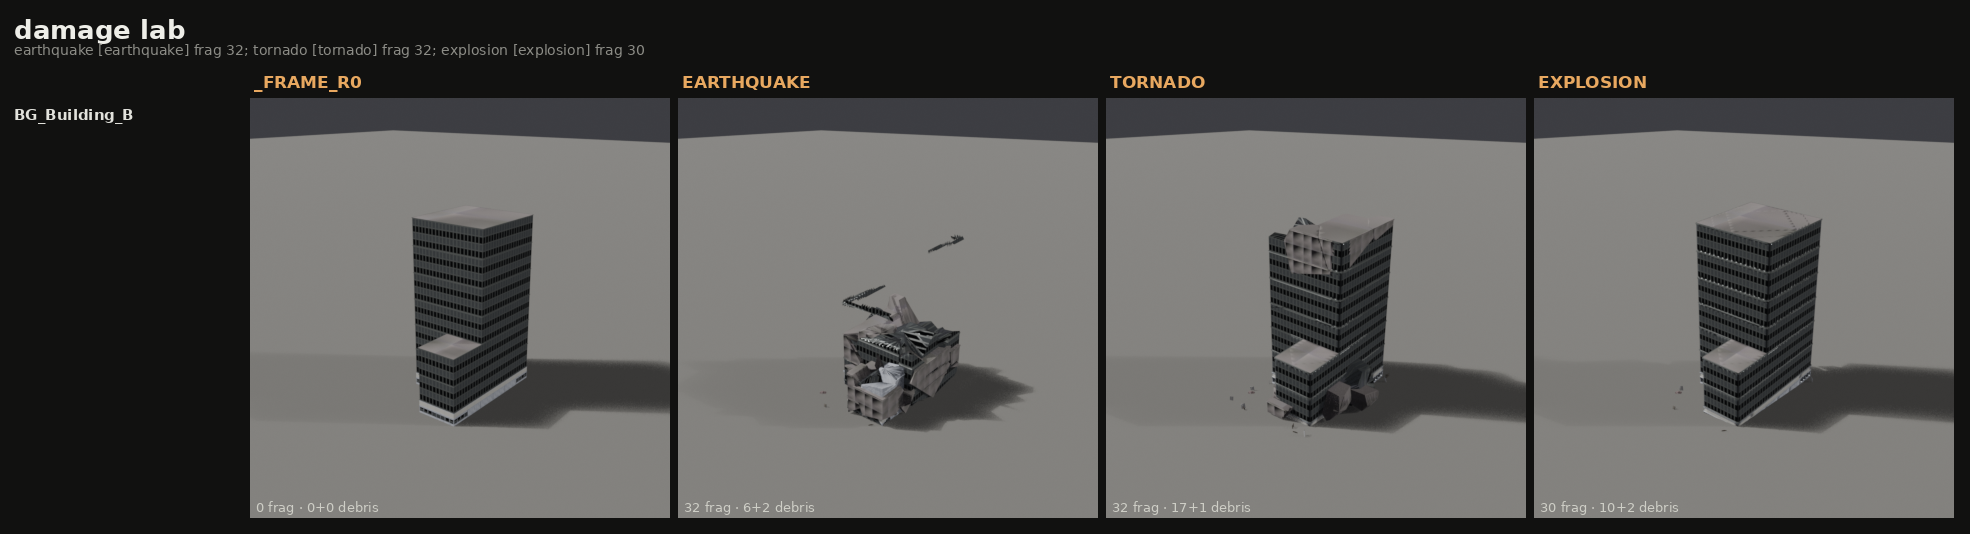

/home/myan2/coasei/AirStack/scene_gen/_damage_lab/render/sheet.png


In [12]:
sheet = dl.render(
    [dl.damage(asset, d, 0.85, seed=7, name=d)
     for d in ("earthquake", "tornado", "explosion")],
    res=420, samples=24)
print(sheet)

## 8. Where the files are

The USDs are on disk in `scene_gen/_damage_lab/` and the Cycles sheet plus its
individual tiles under `scene_gen/_damage_lab/render/`, so anything here can be
opened, re-rendered at higher settings, or handed to the full contact sheet:

```bash
python tools/damage_gallery.py --asset-set suburban --rows 4 --severity 0.8
```

In [13]:
print("USDs written this session:")
for f in sorted(os.listdir(dl.OUT_DIR))[-12:]:
    print("  ", os.path.join(dl.OUT_DIR, f))

USDs written this session:
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/t_old_BG_Building_D..usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/t_old_BG_Building_E..usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/t_old_BG_Building_F..usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/tornado.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/uv_earthquake.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/uv_fire.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/uvchk_plain.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/uvchk_subdiv.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/wt_0.0.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/wt_0.15.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/wt_0.25.usd
   /home/myan2/coasei/AirStack/scene_gen/_damage_lab/wt_0.5.usd
